# 08_优化算法-批量梯度下降法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


在前两次和大家分享完梯度下降法以及随机梯度下降之后，今天给大家带来了**批量梯度下降法**\~

批量梯度下降法（Batch Gradient Descent）是一种非常常用的优化算法，常用于机器学习中的模型训练。

**其核心思想是通过不断调整模型的参数，使损失函数（通常是模型预测值与实际值之间的误差）达到最小。**

具体步骤：

1. **初始化参数**：随机初始化模型的参数。
2. **计算损失**：使用当前参数计算所有训练样本的损失值。
3. **计算梯度**：计算损失函数相对于每个参数的梯度。
4. **更新参数**：按照梯度下降的方向调整参数。更新公式为：$\theta := \theta - \eta \nabla J(\theta)$  
其中，$\theta$ 是模型参数，$\eta$ 是学习率，$\nabla J(\theta)$ 是损失函数的梯度。
5. **重复**：重复步骤2到步骤4，直到损失函数收敛或达到预设的迭代次数。

仍然是这个解释：

假设你在爬一座山，你希望找到这座山的最低点（也就是找到让误差最小的参数）。这座山的高度就相当于你的损失函数，而你所在的位置就是你的参数值。

- **初始化参数**：就像一开始你在山上的某个随机位置。
- **计算损失**：看一下你现在所在位置的高度。
- **计算梯度**：通过观察山的坡度，判断哪个方向是往下的。
- **更新参数**：向坡度下降的方向迈出一步，每一步的大小由学习率决定。
- **重复**：不断重复观察高度、判断坡度、向下走，直到你觉得已经到了山谷底部（损失函数最小）。

批量梯度下降的特别之处在于，每次计算梯度和更新参数时，它都会使用整个训练数据集。这就像每走一步前都要考虑整个山的地形，而不是只看你脚下的一小片区域。这样做可以确保每一步的方向更准确，但也需要更多的计算时间。

## 理论基础

批量梯度下降法（Batch Gradient Descent）是优化问题中的一种方法，用于最小化目标函数。

其基本思想是迭代地调整模型参数，以减小预测值与实际值之间的误差。

### 数学原理

1. **目标函数**：假设我们有一个目标函数 $J(\theta)$，这个函数依赖于参数向量 $\theta$，目标是找到使 $J(\theta)$最小的 $\theta$。
2. **损失函数**：在监督学习中，常用的损失函数是均方误差（MSE）：  
$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$  
其中，$m$是训练样本的数量，$x^{(i)}$是第 $i$个训练样本的特征向量，$y^{(i)}$是第 $i$个训练样本的真实值，$h_\theta(x)$是参数为 $\theta$的模型预测值。
3. **梯度**：梯度是目标函数相对于参数的偏导数，表示函数在参数空间中的变化率。对于每个参数 $\theta_j$，梯度计算如下：  
$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$  
其中，$x_j^{(i)}$是第 $i$个样本的第 $j$个特征值。
4. **参数更新**：使用梯度下降法更新参数，更新公式为：  
$\theta_j := \theta_j - \eta \frac{\partial J(\theta)}{\partial \theta_j}$  
其中，$\eta$是学习率，决定了每次更新的步长。

### 算法流程

**1. 初始化参数**：随机初始化模型参数 $\theta$。

**2. 循环直到收敛**：

**2.1 计算梯度**：

对每个参数 $\theta_j$，计算损失函数的梯度：


$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}
$$


**2.2 更新参数**：

使用梯度下降公式更新每个参数：


$$
\theta_j := \theta_j - \eta \frac{\partial J(\theta)}{\partial \theta_j}
$$


**2.3 计算损失（可选）**：

计算当前参数下的损失值 $J(\theta)$，用于判断算法是否收敛。收敛条件可以是损失函数的变化量小于某个阈值，或者达到预设的最大迭代次数。

### 总结一下

- **初始化**：设定初始参数值。
- **计算梯度**：对于整个数据集计算梯度。
- **更新参数**：按照梯度的反方向更新参数。
- **重复**：重复计算梯度和更新参数的过程，直到损失函数收敛或达到预设的迭代次数。

通过这个过程，批量梯度下降法能够逐步找到使损失函数最小化的参数，从而得到更好的模型预测结果。

## 应用场景

### 批量梯度下降法适用问题

批量梯度下降法（Batch Gradient Descent）适用于需要最小化损失函数的各种机器学习问题，尤其是以下几类：

1. **线性回归**：用于最小化预测值与实际值之间的均方误差。
2. **逻辑回归**：用于二分类问题，最小化交叉熵损失。
3. **神经网络**：用于训练神经网络，通过最小化网络输出与实际标签之间的误差。
4. **支持向量机（SVM）**：用于分类问题，通过最小化Hinge损失。

### 优缺点

**优点**：

1. **全局视角**：每次更新参数时使用整个数据集，能更准确地找到全局最优解。
2. **稳定性**：由于使用全数据集，梯度计算更准确，更新过程更稳定，不易受到噪声的影响。
3. **收敛性好**：对目标函数具有良好的收敛性，适合凸优化问题。

**缺点**：

1. **计算成本高**：每次迭代需要计算所有样本的损失和梯度，计算量大，尤其是对于大规模数据集。
2. **内存消耗大**：需要在内存中存储整个数据集，可能不适用于内存有限的情况。
3. **收敛速度慢**：相比小批量梯度下降和随机梯度下降，收敛速度较慢。

### 运用时的前提条件

1. **数据规模适中**：适用于数据规模不太大的问题，如果数据集过大，可以考虑小批量梯度下降（Mini-batch Gradient Descent）。
2. **凸优化问题**：批量梯度下降法在凸优化问题中效果最佳，因为它保证能找到全局最优解。
3. **充足计算资源**：需要较大的计算资源和内存，以处理整个数据集的梯度计算。

### 实际中的应用案例

1. **广告点击率预测**：在线广告公司使用批量梯度下降法训练逻辑回归模型，预测用户点击广告的概率。由于广告点击数据通常较多，可以通过分批次（小批量）方式进行计算。
2. **房价预测**：房地产公司使用线性回归模型预测房价，利用历史房价数据和房屋特征，通过批量梯度下降法训练模型，找到最优参数，从而做出准确的房价预测。
3. **图像分类**：在图像识别任务中，使用神经网络进行训练，通过批量梯度下降法调整神经网络的参数，提升分类准确率。例如，使用卷积神经网络（CNN）对手写数字进行识别。
4. **金融风险评估**：金融机构使用逻辑回归或神经网络模型评估贷款申请人的风险，通过批量梯度下降法优化模型参数，提高风险评估的准确性。

这些应用案例展示了批量梯度下降法在不同领域的广泛应用，虽然它有计算成本高的缺点，但在准确性和稳定性上具有明显优势。

## 完整案例

我们使用一个房价预测的案例来展示批量梯度下降法。我们使用一个模拟的大数据集，进行线性回归模型训练，并进行数据可视化和算法优化。

**数据集生成**：

我们生成一个模拟的房价数据集，包含房屋面积、房龄、房间数和房价四个特征。

**数据预处理和可视化**：

我们会进行数据预处理，并绘制一些数据分析图形。

**模型训练**：

使用批量梯度下降法训练线性回归模型。

**结果可视化**：

我们会展示训练过程中的损失变化，以及模型的预测结果与实际结果的对比。

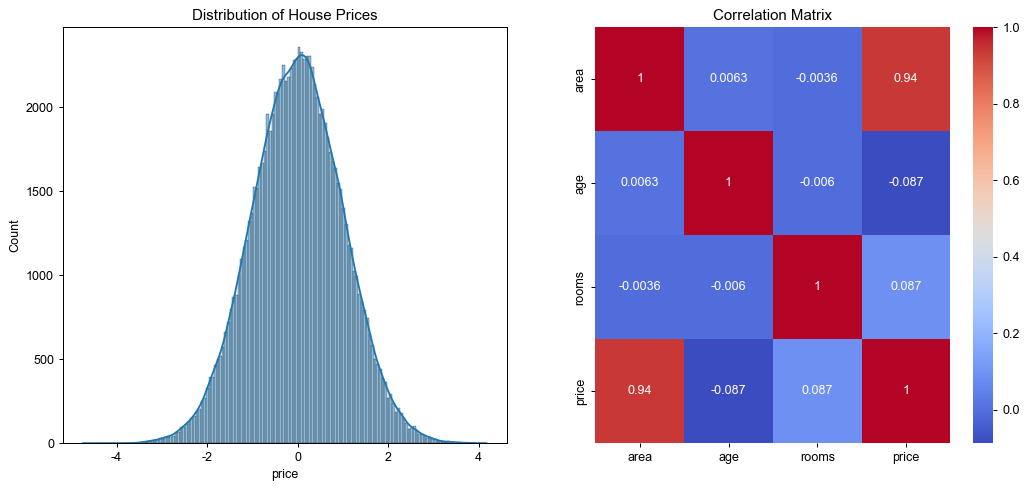

Iteration 0: Cost 2.7881598589024508
Iteration 100: Cost 0.4195151251252746
Iteration 200: Cost 0.099397457820479
Iteration 300: Cost 0.056128572114704435
Iteration 400: Cost 0.05027936758396269


Iteration 500: Cost 0.04948855853115456
Iteration 600: Cost 0.049381628694261784
Iteration 700: Cost 0.04936716839220182
Iteration 800: Cost 0.04936521267625632
Iteration 900: Cost 0.04936494814138837


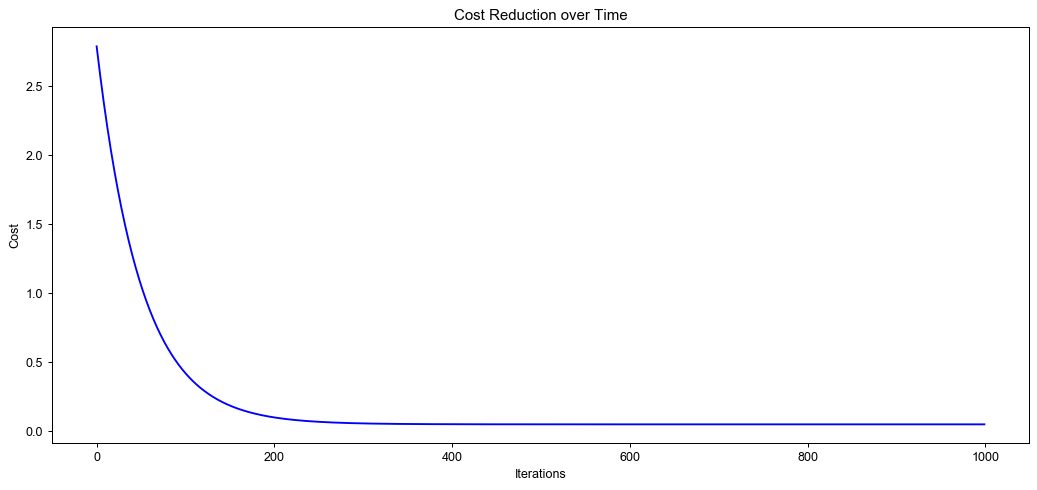

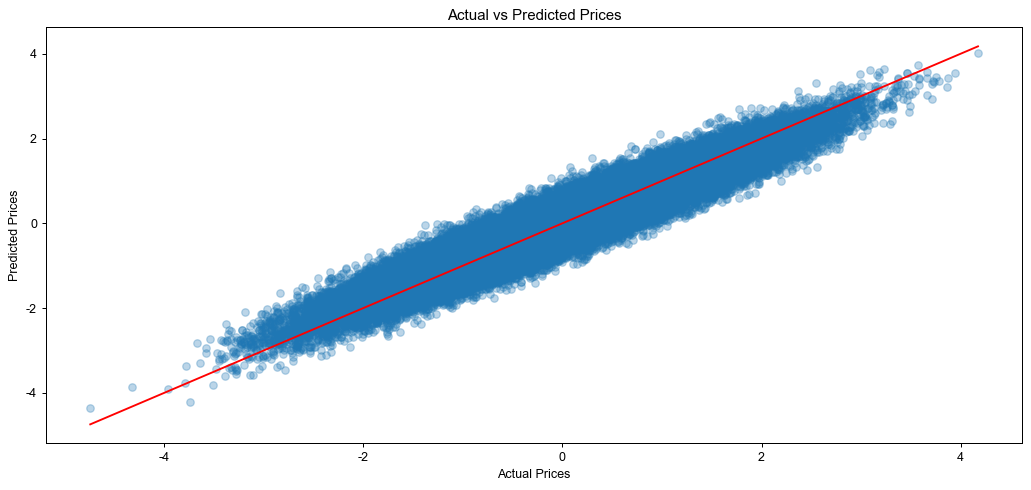

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子
np.random.seed(42)

# 生成模拟数据集
def generate_data(num_samples):
    area = np.random.normal(1500, 500, num_samples)  # 面积
    age = np.random.normal(20, 10, num_samples)      # 房龄
    rooms = np.random.randint(1, 6, num_samples)     # 房间数
    price = (area * 300) + (age * -1500) + (rooms * 10000) + np.random.normal(0, 50000, num_samples)
    return pd.DataFrame({'area': area, 'age': age, 'rooms': rooms, 'price': price})

# 生成10万条数据
data = generate_data(100000)

# 数据预处理
data = (data - data.mean()) / data.std()  # 标准化

# 数据可视化
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(data['price'], kde=True)
plt.title('Distribution of House Prices')
plt.subplot(1, 2, 2)
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 分割数据集
X = data[['area', 'age', 'rooms']].values
y = data['price'].values.reshape(-1, 1)
m = len(y)  # 样本数量

# 添加偏置项
X = np.hstack((np.ones((m, 1)), X))

# 初始化参数
theta = np.random.randn(4, 1)
learning_rate = 0.01
num_iterations = 1000

# 批量梯度下降法
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

cost_history = []

for i in range(num_iterations):
    gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
    theta = theta - learning_rate * gradients
    cost = compute_cost(X, y, theta)
    cost_history.append(cost)
    if i % 100 == 0:
        print(f"Iteration {i}: Cost {cost}")

# 结果可视化
plt.figure(figsize=(14, 6))
plt.plot(range(num_iterations), cost_history, 'b-')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Reduction over Time')
plt.show()

# 模型预测
predictions = X.dot(theta)

# 预测结果与实际结果对比
plt.figure(figsize=(14, 6))
plt.scatter(y, predictions, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

一些细节大家要注意：

1. **数据生成**：生成了一个包含10万条记录的数据集，模拟了房屋面积、房龄、房间数和房价四个特征。
2. **数据预处理**：对数据进行了标准化处理，使得每个特征的均值为0，标准差为1。
3. **数据可视化**：绘制了房价分布直方图和特征之间的相关性热图。
4. **模型训练**：使用批量梯度下降法训练线性回归模型，记录每次迭代的损失值。
5. **结果可视化**：绘制了损失值随迭代次数的变化曲线，以及模型预测结果与实际结果的散点图。

![原文参考图，当前结果见代码输出](attachments/img_011.png)

![原文参考图，当前结果见代码输出](attachments/img_012.png)

![原文参考图，当前结果见代码输出](attachments/img_013.png)

涉及到优化项，大家可以考虑：

1. **学习率调整**：可以尝试不同的学习率，找到最佳学习率，提高收敛速度。
2. **正则化**：添加正则化项，防止过拟合，特别是当特征数量较多时。
3. **特征工程**：增加或改进特征，提升模型的预测能力。